## Project Objective
The goal of this project is to analyze shipment delivery performance,
identify delays (early, on-time, late),
and evaluate their impact on logistics costs.


## Imported Libraries

The following libraries are imported to support data processing, numerical computation, and visualization tasks:

- **`ast`**  
  Enables interaction with Python’s Abstract Syntax Tree (AST), allowing programmatic inspection, analysis, and transformation of Python source code.

- **`pandas (pd)`**  
  Provides high-level data structures and functions for efficient data manipulation, cleaning, and analysis, particularly for tabular datasets.

- **`seaborn (sns)`**  
  A statistical data visualization library built on top of Matplotlib, offering concise syntax and aesthetically enhanced plots.

- **`matplotlib.pyplot (plt)`**  
  A foundational plotting library used to create static, animated, and interactive visualizations.

- **`numpy (np)`**  
  Supports numerical computing through efficient multi-dimensional arrays and a comprehensive set of mathematical functions.


In [43]:
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

## Data Loading

The dataset is loaded into a Pandas DataFrame using the `read_csv` function:

- **`pd.read_csv()`**  
  Reads a CSV (Comma-Separated Values) file from the specified file path and converts it into a Pandas DataFrame.

- **File Path**  
  The file path points to a local dataset containing supply chain shipment pricing data.

- **`df`**  
  The resulting DataFrame stores the loaded dataset and serves as the primary structure for subsequent data exploration, cleaning, and analysis.

This step initializes the dataset for further analytical and visualization tasks.


In [44]:
df = pd.read_csv(r'c:\Users\HP\Downloads\Supply_Chain_Shipment_Pricing_Data.csv')
df

,id,project code,pq #,po / so #,asn/dn #,country,managed by,fulfill via,vendor inco term,shipment mode,...,unit of measure (per pack),line item quantity,line item value,pack price,unit price,manufacturing site,first line designation,weight (kilograms),freight cost (usd),line item insurance (usd)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,...,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,True,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,...,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",True,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,...,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,True,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",True,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,...,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",True,7590,45450.08,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,FPQ-15197,SO-50020,DN-4307,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",False,See DN-4307 (ID#:83920),See DN-4307 (ID#:83920),705.79
10320,86819,104-CI-T30,FPQ-15259,SO-50102,DN-4313,Côte d'Ivoire,PMO - US,From RDC,N/A - From RDC,Truck,...,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,False,See DN-4313 (ID#:83921),See DN-4313 (ID#:83921),161.71
10321,86821,110-ZM-T30,FPQ-14784,SO-49600,DN-4316,Zambia,PMO - US,From RDC,N/A - From RDC,Truck,...,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,False,Weight Captured Separately,Freight Included in Commodity Cost,5284.04
10322,86822,200-ZW-T30,FPQ-16523,SO-51680,DN-4334,Zimbabwe,PMO - US,From RDC,N/A - From RDC,Truck,...,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,True,1392,Freight Included in Commodity Cost,134.03


## Dataset Structure Inspection

The `df.info()` method is used to examine the structure of the dataset, including:

- The total number of records and columns
- Column names
- Non-null value counts
- Data types
- Memory usage

This step helps identify missing values, inappropriate data types, and columns requiring preprocessing.

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            10324 non-null  int64  
 1   project code                  10324 non-null  object 
 2   pq #                          10324 non-null  object 
 3   po / so #                     10324 non-null  object 
 4   asn/dn #                      10324 non-null  object 
 5   country                       10324 non-null  object 
 6   managed by                    10324 non-null  object 
 7   fulfill via                   10324 non-null  object 
 8   vendor inco term              10324 non-null  object 
 9   shipment mode                 9964 non-null   object 
 10  pq first sent to client date  10324 non-null  object 
 11  po sent to vendor date        10324 non-null  object 
 12  scheduled delivery date       10324 non-null  object 
 13  d

## Column Selection

A subset of relevant columns is selected to focus the analysis on shipment, vendor, and cost-related attributes.  
Reducing the number of columns improves clarity, performance, and analytical relevance.

The selected columns include:
- Geographic and vendor information
- Shipment and product classification details
- Key shipment dates
- Cost and insurance values

The filtered dataset is reassigned to the DataFrame for further processing.


In [46]:
cols_to_keep = [
    'country', 'vendor', 'shipment mode',
    'product group', 'sub classification',
    'po sent to vendor date', 'scheduled delivery date',
    'delivered to client date',
    'freight cost (usd)', 'line item insurance (usd)'
]

df = df[cols_to_keep]


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country                    10324 non-null  object 
 1   vendor                     10324 non-null  object 
 2   shipment mode              9964 non-null   object 
 3   product group              10324 non-null  object 
 4   sub classification         10324 non-null  object 
 5   po sent to vendor date     10324 non-null  object 
 6   scheduled delivery date    10324 non-null  object 
 7   delivered to client date   10324 non-null  object 
 8   freight cost (usd)         10324 non-null  object 
 9   line item insurance (usd)  10037 non-null  float64
dtypes: float64(1), object(9)
memory usage: 806.7+ KB


## Date Type Conversion

Certain date-related columns were initially stored as object (string) types.  
These columns are explicitly converted to datetime format using `pd.to_datetime()` to enable accurate date-based calculations and comparisons.

Converted columns:
- `scheduled delivery date`
- `delivered to client date`

This conversion ensures consistency and allows for time-series analysis, delay calculations, and proper sorting.


In [48]:
list_to_date = ['scheduled delivery date', 'delivered to client date']

df = df.copy()                                          # To avoid SettingWithCopyWarning

for col in list_to_date:
    df[col] = pd.to_datetime(df[col], format='mixed')    # mixed format handles different date formats

## Post-Processing Validation

After column selection and data type conversion, `df.info()` is executed again to validate:

- Successful reduction of columns
- Correct datetime data types
- Updated memory usage

In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   country                    10324 non-null  object        
 1   vendor                     10324 non-null  object        
 2   shipment mode              9964 non-null   object        
 3   product group              10324 non-null  object        
 4   sub classification         10324 non-null  object        
 5   po sent to vendor date     10324 non-null  object        
 6   scheduled delivery date    10324 non-null  datetime64[ns]
 7   delivered to client date   10324 non-null  datetime64[ns]
 8   freight cost (usd)         10324 non-null  object        
 9   line item insurance (usd)  10037 non-null  float64       
dtypes: datetime64[ns](2), float64(1), object(7)
memory usage: 806.7+ KB


# To what extent do shipment delays occur?

### Methodology

- To evaluate shipment delivery performance, the dataset was first cleaned and relevant variables were selected. Scheduled and actual delivery date fields were converted to datetime format to enable accurate date-based calculations.

- Delivery delay was calculated as the difference, in days, between the scheduled delivery date and the actual delivery date. Based on this calculated delay, shipments were classified into three categories: early, on time, and late.

- Frequency analysis was conducted to determine the distribution of delivery delays and delivery status. Visualizations, including bar charts and pie charts, were used to illustrate delay distributions and the proportion of shipments by delivery status.

This methodology provides both quantitative and visual insights into shipment timeliness and overall delivery performance.


## Delivery Delay Calculation

A copy of the cleaned dataset is created to preserve the original DataFrame and allow independent analysis of delivery delays.

```python
df_delai = df.copy()


In [50]:
df_delai = df.copy()

In [51]:
df_delai['delay'] = (
    df_delai['scheduled delivery date'] - df_delai['delivered to client date']
    ).dt.days

df_delai



,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0
...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36


## Delay Frequency Distribution

The frequency of shipment delays is analyzed using the `value_counts()` method applied to the `delay` column.

The resulting output shows the number of occurrences for each unique delay value, limited to the most frequent observations for clarity.

This step helps identify dominant delivery patterns, such as the prevalence of on-time deliveries and commonly occurring early or late delivery durations.


In [52]:
df_delai_count = df_delai.value_counts('delay').head(19).to_frame()
df_delai_count

,count
delay,
0,6324
17,127
6,119
8,112
13,107
7,106
2,93
-1,92
19,85


## Visualization of Shipment Delay Distribution

A bar chart is used to visualize the distribution of shipment delays based on their frequency.

The Seaborn visualization style is configured to use a clean, publication-friendly theme with axis ticks enabled. A bar plot is then generated using the delay values on the x-axis and the corresponding number of shipments on the y-axis.

Color encoding is applied based on shipment count to enhance visual differentiation between frequently and infrequently occurring delay values. Non-essential plot borders are removed to improve readability.

Axis labels and a descriptive title are added to clearly communicate the meaning of the visualization. The y-axis is constrained to focus on the relevant range of shipment counts, and layout adjustments are applied to prevent label overlap.

This visualization provides a clear overview of delivery performance, highlighting the most common delay durations and the overall distribution of shipment timeliness.


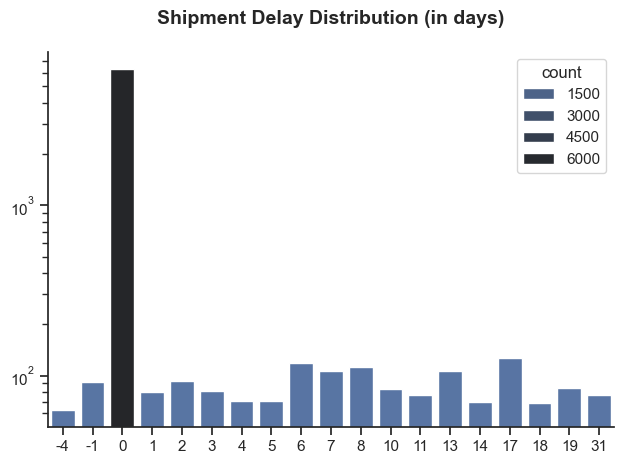

In [53]:
sns.set_theme(style = 'ticks')
sns.barplot(data = df_delai_count,
            x = 'delay',
            y = 'count',           
            hue = 'count',
            palette = 'dark:b_r',
           )
sns.despine()                                        # Remove the top and right spines from plot


plt.yscale("log")
plt.xlabel('')
plt.ylabel('')
plt.title('Shipment Delay Distribution (in days)', pad = 20, fontsize = 14, fontweight = 'bold')

plt.tight_layout()
plt.show()

**Insight:**  
Shipment delays are **heavily concentrated around zero days**, indicating that most deliveries occur on time or with minimal deviation. However, the distribution shows a **long tail of positive delays**, with a smaller number of shipments experiencing extended delays of more than two weeks. Early deliveries occur less frequently and remain limited in scope.

**Key Takeaways:**  
- The majority of delays are **short and operationally manageable**.  
- A small number of **severe delay cases disproportionately impact performance and customer experience**.  
- Focusing on the root causes of extreme delays would deliver **outsized improvements in overall reliability**.


## Shipment Delivery Status Classification

A new categorical variable, `shipment delivery`, is created to classify each shipment based on its delivery performance relative to the scheduled delivery date.

The classification logic is defined as follows:
- Shipments delivered **before** the scheduled date are labeled as **early**.
- Shipments delivered **on** the scheduled date are labeled as **on time**.
- Shipments delivered **after** the scheduled date are labeled as **late**.

This categorization is implemented using conditional logic to efficiently assign delivery status across all records.

The resulting variable enables grouped analysis and comparison of shipment performance across vendors, countries, and shipment modes.


In [54]:
df_delai['shipment delivery'] = np.where(
    df_delai['delay'] < 0 , 'early',                         # if delay < 0 then 'early'
    np.where(                                                # if delay = 0 then 'on time'
        df_delai['delay'] == 0, 'on time',                   # else 'late'
    'late')
)

df_delai

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6,early
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


## Shipment Delivery Status Distribution

A pie chart is used to visualize the proportion of shipments by delivery status, categorized as early, on time, or late.

The chart is generated by computing the frequency of each delivery status and displaying their relative contributions as percentages of the total number of shipments. Percentage labels are included to provide precise quantitative insight into each category.

The visualization offers an intuitive overview of overall delivery performance, clearly illustrating the balance between on-time, early, and delayed shipments. This representation supports high-level assessment of operational efficiency and service reliability.


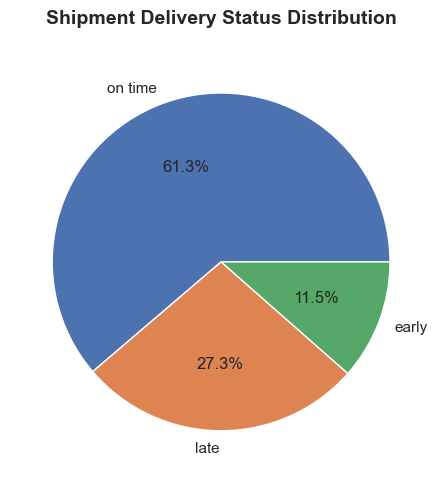

In [55]:
df_delai['shipment delivery'].value_counts().plot(kind = 'pie',
                xlabel = '', 
                ylabel = '',
                figsize = (8,5),
                autopct = '%1.1f%%',                # Show percentages on pie chart
                
                  )

plt.title('Shipment Delivery Status Distribution', pad = 20, fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()

**Insight:**  
Overall delivery performance is stable, with **61.3% of shipments delivered on time**. However, a **material 27.3% of shipments arrive late**, indicating a meaningful service gap. **Early deliveries account for 11.5%**, which may signal planning or scheduling misalignment rather than performance gains.

**Key Takeaways:**  
- Reducing late deliveries should be a **primary operational priority**.  
- Early shipments suggest opportunities to **better align planning with customer delivery windows**.  
- Targeted improvements in **high-risk modes and countries** could significantly lift overall service performance.


-----------------------------------------------------------------------------------------------

## Shipment Mode Performance Analysis

### Objective
This analysis evaluates delivery performance across different shipment modes by examining the percentage distribution of delivery outcomes (early, late, and on-time).

### Methodology
The analysis was conducted in three stages:
1. Aggregation of shipment counts by shipment mode and delivery status
2. Conversion of shipment counts into percentage values per shipment mode
3. Visualization of percentage distributions using a bar chart

This approach ensures comparability between shipment modes regardless of shipment volume.

### Data Aggregation
A pivot table was created to summarize shipment counts by shipment mode and delivery status.

In [56]:
df_mode = df_delai.pivot_table(index= 'shipment mode',
                     columns= 'shipment delivery',
                     aggfunc= 'size',
                     )

df_mode

shipment delivery,early,late,on time
shipment mode,,,
Air,587,1183,4343
Air Charter,75,452,123
Ocean,65,15,291
Truck,455,1137,1238


### Percentage Calculation

Shipment totals were calculated for each shipment mode, and delivery outcomes were converted into percentages.

In [57]:
df_mode['total'] = df_mode.sum(axis=1)



df_mode_prc = df_mode.iloc[:].div(df_mode['total'] / 100, axis = 0)

df_mode_prc.drop(columns = 'total', inplace = True)

df_mode_prc


shipment delivery,early,late,on time
shipment mode,,,
Air,9.602487,19.352200,71.045313
Air Charter,11.538462,69.538462,18.923077
Ocean,17.520216,4.043127,78.436658
Truck,16.077739,40.176678,43.745583


### Visualization

The percentage distribution of delivery outcomes by shipment mode was visualized using a bar chart.

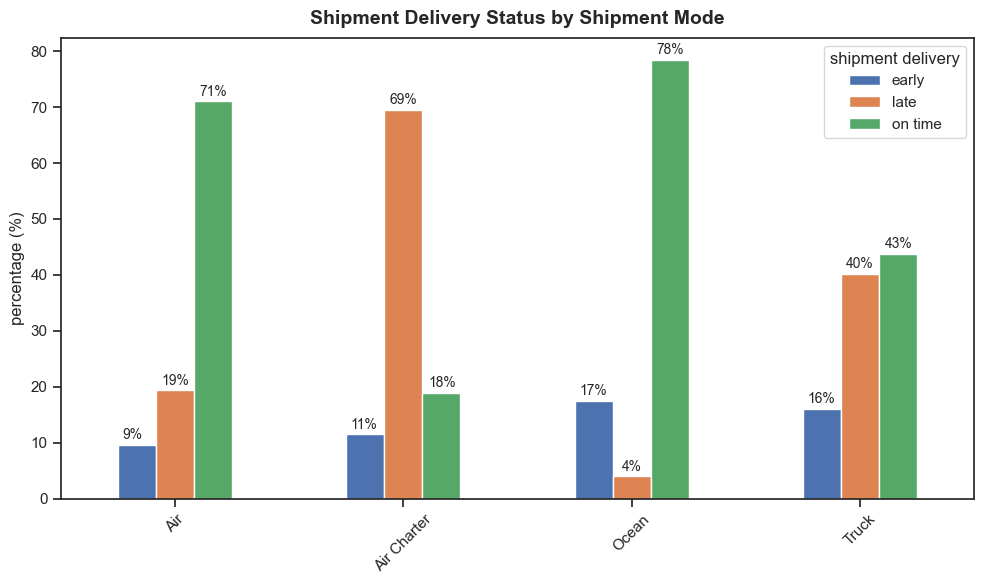

In [58]:
df_mode_prc.plot(kind = 'bar',
            figsize = (10,6),
            xlabel = '',
            ylabel = 'percentage (%)',
             )

for i, j in enumerate(df_mode_prc['early']):
    plt.text(i-0.23, j + 1,  f'{int(j)}%', fontsize = 10, ha = 'left' )
    
for i, j in enumerate(df_mode_prc['late']):
    plt.text(i, j + 1,  f'{int(j)}%', fontsize = 10, ha = 'center')

for i, j in enumerate(df_mode_prc['on time']):
    plt.text(i+0.23, j + 1,  f'{int(j)}%', fontsize = 10, ha = 'right')
    
plt.title('Shipment Delivery Status by Shipment Mode', pad = 10, fontsize = 14, fontweight = 'bold')
plt.xticks(rotation = 45 )
plt.tight_layout()

plt.show()

**Insight:**  
Delivery performance varies significantly by shipment mode. **Ocean freight is the most reliable**, with **78% of shipments delivered on time** and minimal delays (4%), making it well-suited for planned, non-urgent shipments. **Air transport performs strongly**, achieving **71% on-time delivery**, though with moderate delay exposure (19%). In contrast, **Air Charter shows poor reliability**, with **69% of shipments delivered late** and limited on-time performance (18%). **Truck shipments display mixed results**, with on-time deliveries (43%) closely aligned with late deliveries (40%).

**Key Takeaways:**  
- **Ocean freight is underutilized relative to its reliability**, representing an opportunity for mode optimization.  
- **Air Charter is the primary performance risk** and requires focused corrective action.  
- Truck performance can be improved through **route planning and scheduling optimization**.  
- Better alignment between **shipment urgency and transport mode** would improve service levels and cost efficiency.



-------------------------------------------------------------------------------------------------

## Shipment Mode Distribution

### Objective
This analysis aims to examine the overall distribution of shipment modes within the dataset in order to understand their relative frequency.

### Methodology
The distribution of shipment modes was calculated using a frequency count. The results were then visualized using a pie chart to illustrate the proportion of each shipment mode.

### Data Aggregation
Shipment mode frequencies were computed as follows:

In [59]:
df_mode_4 = df_delai['shipment mode'].value_counts()

df_mode_4

shipment mode
Air            6113
Truck          2830
Air Charter     650
Ocean           371
Name: count, dtype: int64

### Visualization

A pie chart was used to represent the percentage share of each shipment mode.

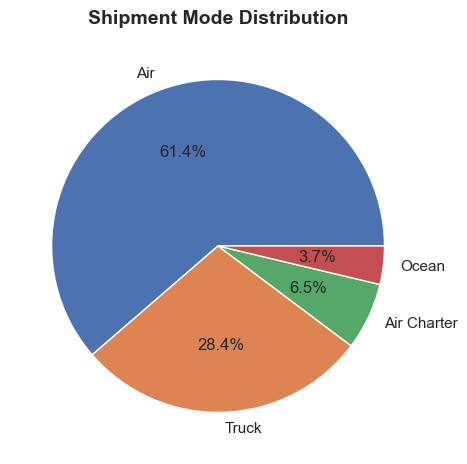

In [60]:
df_mode_4.plot(kind = 'pie',
               xlabel = '',
               ylabel = '',
               autopct = '%1.1f%%',
               )

plt.title('Shipment Mode Distribution', pad = 10, fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.show()


**Insight:**  
The shipment mix is **heavily skewed toward Air transport**, which accounts for **61.4% of total shipments**, reflecting a strong focus on speed and responsiveness. **Truck shipments** represent **28.4%**, serving as the primary ground transport option. **Air Charter (6.5%)** and **Ocean freight (3.7%)** are used selectively, indicating limited adoption of more cost-efficient modes.

**Key Takeaways:**  
- Heavy reliance on Air transport likely **drives higher logistics costs** and increases exposure to delay variability.  
- **Ocean freight remains underutilized**, despite strong on-time performance, suggesting potential for mode rebalancing.  
- Optimizing mode selection based on shipment urgency could improve **cost efficiency and delivery reliability**.


-------------------------------------------------------------------------------------------------

## Shipment Performance by Country

### Objective
This section analyzes shipment distribution and delivery performance across countries, with a focus on the most active countries in the dataset.

---

## Top Countries by Shipment Volume

### Methodology
Countries were ranked based on the total number of shipments. The top 19 countries with the highest shipment volumes were selected for further analysis.

### Data Aggregation
Shipment counts by country were calculated as follows:


In [61]:
top19_country = df_delai['country'].value_counts().head(19).to_frame()

top19_country

,count
country,
South Africa,1406
Nigeria,1194
Côte d'Ivoire,1083
Uganda,779
Vietnam,688
Zambia,683
Haiti,655
Mozambique,631
Zimbabwe,538


### Visualization

A bar chart was used to display the shipment volume of the top 19 countries.

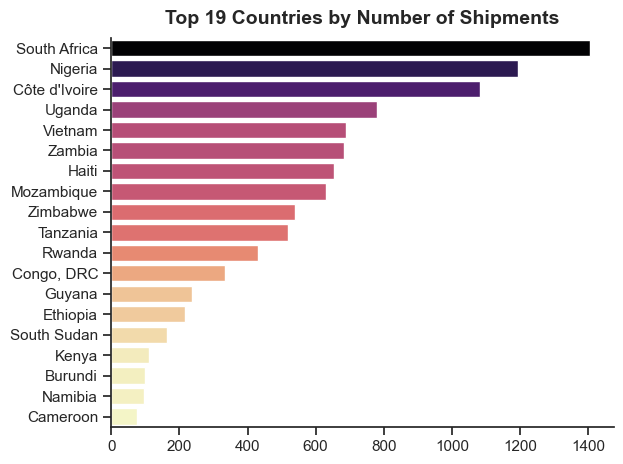

In [62]:
sns.set_theme(style = 'ticks')
sns.barplot(data = top19_country,
            x = 'count',
            y = 'country',
            hue = 'count',
            palette = 'magma_r'
            )
sns.despine()                                        # Remove the top and right spines from plot

plt.xlabel('')
plt.ylabel('')
plt.title('Top 19 Countries by Number of Shipments', pad = 10, fontsize = 14, fontweight = 'bold')

plt.legend().remove()
plt.tight_layout()
plt.show()

**Insight:**  
Shipment volumes are **highly concentrated in a small number of countries**, led by **South Africa and Nigeria**, which together represent a substantial share of total shipments. A second tier—**Côte d'Ivoire, Uganda, Vietnam, and Zambia**—shows meaningful activity, indicating important regional hubs. Beyond the top group, shipment volumes decline sharply, reflecting a **long-tail distribution** across remaining countries.

**Key Takeaways:**  
- The shipment network shows **strong dependence on a few core markets**, increasing concentration risk.  
- High-volume countries offer clear opportunities for **route optimization, consolidation, and strategic carrier agreements**.  
- Lower-volume destinations may benefit from **regional aggregation or hub-and-spoke strategies** to improve efficiency and cost control.


## Delivery Performance in Top 3 Countries

## Methodology

The three countries with the highest shipment volumes were selected to analyze delivery performance in greater detail.

In [63]:
top3_country = df_delai['country'].value_counts().head(3).index

top3_country

Index(['South Africa', 'Nigeria', 'Côte d'Ivoire'], dtype='object', name='country')

In [64]:
df_top3 = df_delai[df_delai['country'].isin(top3_country)]

df_top3

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
5,Nigeria,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-09-28,2006-09-28,5920.42,NaN,0,on time
8,Nigeria,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-12-07,2006-12-07,See ASN-93 (ID#:1281),NaN,0,on time
12,Nigeria,EY Laboratories,Air,HRDT,HIV test,Date Not Captured,2007-01-10,2007-01-10,Invoiced Separately,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10314,Nigeria,SCMS from RDC,Air Charter,ARV,Pediatric,N/A - From RDC,2015-06-30,2015-05-15,See DN-4274 (ID#:84472),38.27,46,late
10315,Nigeria,SCMS from RDC,Air Charter,ARV,Adult,N/A - From RDC,2015-06-30,2015-05-15,26180,1341.33,46,late
10316,Nigeria,SCMS from RDC,Air Charter,ARV,Adult,N/A - From RDC,2015-06-02,2015-05-15,3410,115.11,18,late
10317,Nigeria,SCMS from RDC,Air,ARV,Adult,N/A - From RDC,2015-06-30,2015-06-22,See DN-4282 (ID#:83919),24.69,8,late


### Data Aggregation

A pivot table was created to summarize delivery outcomes by country.

In [65]:
df_top3_pvt = df_top3.pivot_table(index = 'country',
                    columns = 'shipment delivery',
                    aggfunc = 'size').sort_values(by = 'on time', ascending = False)

df_top3_pvt['total'] = df_top3_pvt.sum(axis=1)

df_top3_pvt

shipment delivery,early,late,on time,total
country,,,,
South Africa,115,278,1013,1406
Côte d'Ivoire,134,349,600,1083
Nigeria,142,557,495,1194


In [66]:
for col in ['early', 'on time', 'late']:
    df_top3_pvt[col] = (df_top3_pvt[col] / df_top3_pvt['total']) * 100

df_top3_pvt.drop(columns = 'total', inplace = True)
df_top3_pvt

shipment delivery,early,late,on time
country,,,
South Africa,8.179232,19.772404,72.048364
Côte d'Ivoire,12.373038,32.225300,55.401662
Nigeria,11.892797,46.649916,41.457286


### Visualization

Pie charts were used to illustrate the percentage distribution of delivery outcomes for each of the top three countries.

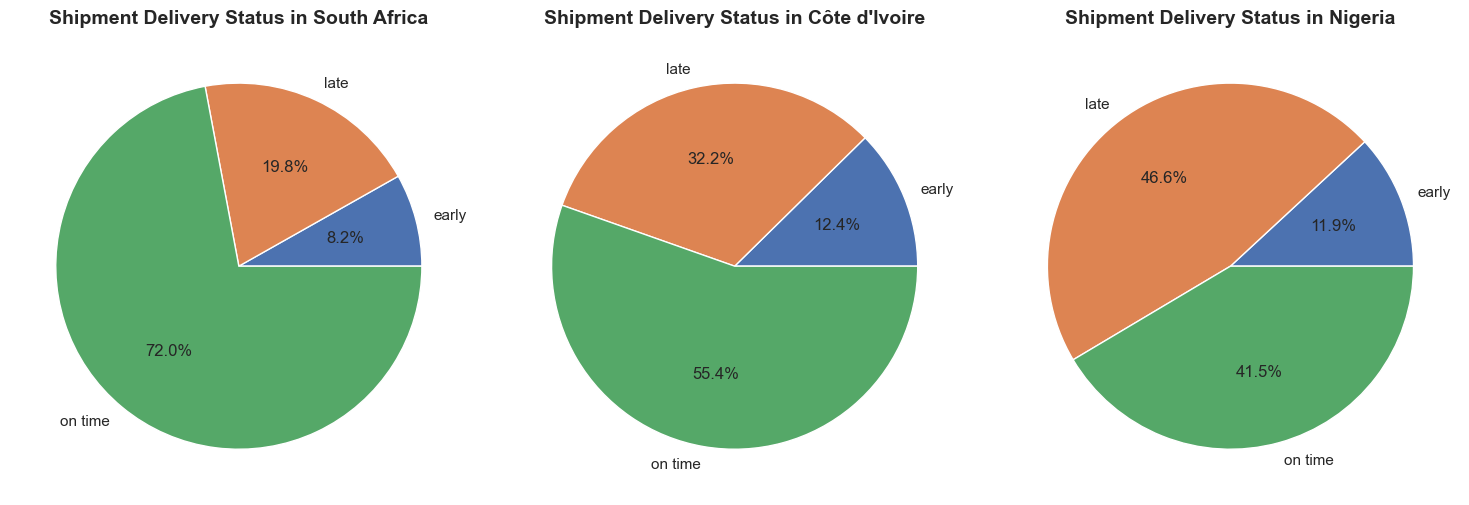

In [67]:
fig , ax = plt.subplots(1, 3, figsize = (15,5))

for i, country in enumerate(df_top3_pvt.index):
    df_top3_pvt.loc[country].plot(kind = 'pie',
                                  ax = ax[i],
                                  xlabel = '',
                                  ylabel = '',
                                  autopct = '%1.1f%%',
                                  )
    ax[i].set_title(f'Shipment Delivery Status in {country}', pad = 10, fontsize = 14, fontweight = 'bold')
    ax[i].legend().remove()
plt.tight_layout()
plt.show()
    
    

**Insight:**  
Delivery performance differs materially across key countries. **South Africa demonstrates strong reliability**, with **72.0% of shipments delivered on time** and a relatively low late rate (19.8%), indicating mature and stable logistics execution. **Côte d'Ivoire shows moderate performance**, with **55.4% on-time deliveries** and a meaningful share of late shipments (32.2%), suggesting operational improvement potential. **Nigeria presents the greatest challenge**, where **late deliveries (46.6%) exceed on-time performance (41.5%)**, pointing to structural or execution-related constraints.

**Key Takeaways:**  
- South Africa can serve as a **benchmark market** for delivery performance best practices.  
- Côte d'Ivoire requires **targeted process improvements** to reduce delays.  
- Nigeria should be a **priority focus area**, as improving delivery reliability there would have a significant impact on overall service levels.


-------------------------------------------------------------------------------------------------

# Does shipment delivery status affect freight costs?
### Objective
This analysis examines the relationship between **shipment delivery status** and **freight cost**, with a focus on comparing median freight costs for late and on-time shipments across shipment modes.


## Data Preparation


In [68]:
df_C = df_delai.copy()
df_C

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6,early
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


In [69]:
df_C = df_C[df_C['shipment delivery'].isin(['on time', 'late'])]

df_C

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10318,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),869.66,16,late
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


### Data Cleaning
To ensure accurate cost analysis, the dataset was filtered and cleaned as follows:
- Removed missing freight cost values
- Converted freight cost values to numeric format
- Retained only shipments with delivery status classified as *on time* or *late*

In [70]:
df_C['freight cost (usd)'].value_counts()

freight cost (usd)
Freight Included in Commodity Cost    1390
Invoiced Separately                    224
9736.1                                  33
See DN-304 (ID#:10589)                  16
6147.18                                 16
                                      ... 
See DN-4265 (ID#:83335)                  1
See DN-4274 (ID#:84472)                  1
26180                                    1
3410                                     1
See DN-4282 (ID#:83919)                  1
Name: count, Length: 5984, dtype: int64

In [71]:
df_C = df_C.copy()

df_C["freight cost (usd)"] = pd.to_numeric(df_C["freight cost (usd)"] , errors="coerce")

df_C["freight cost (usd)"]

0          780.34
1         4521.50
2         1653.78
3        16007.06
4        45450.08
           ...   
10318         NaN
10319         NaN
10321         NaN
10322         NaN
10323         NaN
Name: freight cost (usd), Length: 9138, dtype: float64

In [72]:
df_C = df_C.dropna(subset=["freight cost (usd)"])

df_C.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5454 entries, 0 to 10316
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   country                    5454 non-null   object        
 1   vendor                     5454 non-null   object        
 2   shipment mode              5245 non-null   object        
 3   product group              5454 non-null   object        
 4   sub classification         5454 non-null   object        
 5   po sent to vendor date     5454 non-null   object        
 6   scheduled delivery date    5454 non-null   datetime64[ns]
 7   delivered to client date   5454 non-null   datetime64[ns]
 8   freight cost (usd)         5454 non-null   float64       
 9   line item insurance (usd)  5266 non-null   float64       
 10  delay                      5454 non-null   int64         
 11  shipment delivery          5454 non-null   object        
dtypes: datetim

### Methodology

Median freight costs were calculated for each delivery status to reduce the influence of extreme values.

In [73]:
df_C_plot = df_C.groupby('shipment delivery')['freight cost (usd)'].median().to_frame()

df_C_plot

,freight cost (usd)
shipment delivery,
late,7363.74
on time,4851.00


### Visualization

A bar chart was used to compare median freight costs between late and on-time shipments.

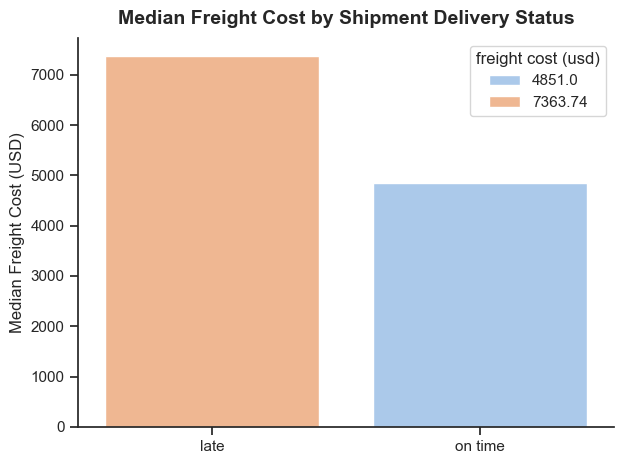

In [74]:
sns.set_theme(style = 'ticks')
sns.barplot(data = df_C_plot,
            x = 'shipment delivery',
            y = 'freight cost (usd)',
            palette = 'pastel',
            hue = 'freight cost (usd)',
            )
sns.despine()

plt.title('Median Freight Cost by Shipment Delivery Status', pad = 10, fontsize = 14, fontweight = 'bold')
plt.xlabel('')
plt.ylabel('Median Freight Cost (USD)')

plt.tight_layout()
plt.show()

**Insight:**  
Late shipments carry a **significant cost premium**, with a median freight cost of approximately **USD 7.4K**, compared to **USD 4.9K for on-time deliveries**. This represents a **~50% increase in cost** when shipments fail to meet delivery schedules.

**Key Takeaways:**  
- Delivery delays have a **direct and material impact on freight spend**.  
- Improving on-time performance offers a **clear opportunity for cost reduction** without increasing shipment volume.  
- Cost-control efforts should focus on **preventing delays rather than managing them after they occur**.



--------------------------------------------------------------------------

## Freight Cost by Shipment Mode and Delivery Status

### Methodology

The dataset was split by delivery status, and median freight costs were calculated for each shipment mode.

In [75]:
df_C_late = df_C[df_C['shipment delivery'] == 'late']

df_C_on_time = df_C[df_C['shipment delivery'] == 'on time']

### Visualization

Two side-by-side bar charts were used to compare median freight costs by shipment mode for late and on-time deliveries.

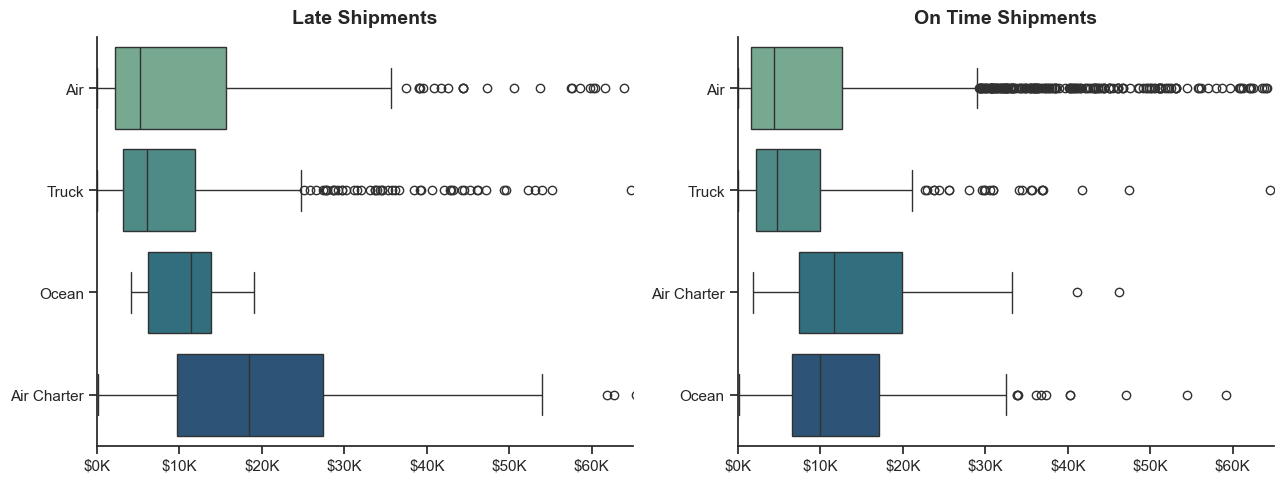

In [76]:
fig , ax = plt.subplots(1,2, figsize=(13,5))

sns.set_theme(style = 'ticks')
sns.boxplot(data = df_C_late,
            x = 'freight cost (usd)',
            y = 'shipment mode',
            ax = ax[0],
            palette='crest',
            hue= 'shipment mode',
            legend=False,
            )
ax[0].set_title('Late Shipments', fontsize=14, fontweight='bold', pad=10)
ax[0].set_xlabel('')
ax[0].set_ylabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
ax[0].set_xlim(0, 65000)

sns.boxplot(data = df_C_on_time,
            x = 'freight cost (usd)',
            y = 'shipment mode',
            ax = ax[1],
            hue='shipment mode',
            palette='crest',
            legend=False,
            )
ax[1].set_title('On Time Shipments', fontsize=14, fontweight='bold', pad=10)
ax[1].set_xlabel('')
ax[1].set_ylabel('')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${int(x/1000)}K"))
ax[1].set_xlim(0, 65000)

sns.despine()

plt.tight_layout()

plt.show()

**Insight:**  
Freight cost distributions vary significantly by shipment mode and delivery outcome. **Late shipments show higher median costs and greater cost volatility across all modes**, with **Air Charter exhibiting the widest spread and highest cost exposure**, indicating substantial financial risk when delays occur. In comparison, **on-time shipments demonstrate lower and more controlled cost distributions**, though premium modes such as Air Charter and Ocean still carry higher baseline costs.

**Key Takeaways:**  
- Delivery delays are associated with both **higher freight costs and increased cost variability**.  
- **Air Charter represents the highest cost-risk profile**, particularly when shipments are delayed.  
- Improving reliability in high-cost modes would deliver **disproportionate cost and performance benefits**.  
- Cost governance efforts should prioritize **preventing delays rather than absorbing their financial impact**.



--------------------------------------------------------------------------------------------------------

In [77]:
df_delai

,country,vendor,shipment mode,product group,sub classification,po sent to vendor date,scheduled delivery date,delivered to client date,freight cost (usd),line item insurance (usd),delay,shipment delivery
0,Côte d'Ivoire,RANBAXY Fine Chemicals LTD.,Air,HRDT,HIV test,Date Not Captured,2006-06-02,2006-06-02,780.34,NaN,0,on time
1,Vietnam,Aurobindo Pharma Limited,Air,ARV,Pediatric,Date Not Captured,2006-11-14,2006-11-14,4521.5,NaN,0,on time
2,Côte d'Ivoire,Abbott GmbH & Co. KG,Air,HRDT,HIV test,Date Not Captured,2006-08-27,2006-08-27,1653.78,NaN,0,on time
3,Vietnam,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,Air,ARV,Adult,Date Not Captured,2006-09-01,2006-09-01,16007.06,NaN,0,on time
4,Vietnam,Aurobindo Pharma Limited,Air,ARV,Adult,Date Not Captured,2006-08-11,2006-08-11,45450.08,NaN,0,on time
...,...,...,...,...,...,...,...,...,...,...,...,...
10319,Zimbabwe,SCMS from RDC,Truck,ARV,Pediatric,N/A - From RDC,2015-07-31,2015-07-15,See DN-4307 (ID#:83920),705.79,16,late
10320,Côte d'Ivoire,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-07-31,2015-08-06,See DN-4313 (ID#:83921),161.71,-6,early
10321,Zambia,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-08-31,2015-08-25,Freight Included in Commodity Cost,5284.04,6,late
10322,Zimbabwe,SCMS from RDC,Truck,ARV,Adult,N/A - From RDC,2015-09-09,2015-08-04,Freight Included in Commodity Cost,134.03,36,late


In [89]:
prod_i = df_delai['product group'].value_counts().head(3).index

In [95]:
df_delai.pivot_table(index='product group',
                     columns = 'shipment delivery',
                     aggfunc = 'size',
                     fill_value = 0,
                
                     ).sort_values(by=prod_i, ascending=False)

KeyError: Index(['ARV', 'HRDT', 'ANTM'], dtype='object', name='product group')